# Import Libraries

In [28]:
# Basic Machine Learning libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Task 1
Load the wine-missing.csv dataset into a DataFrame using the pandas library. Then, describe each feature and create their corresponding histogram. For the Type variable, create a bar chart for the values ​​white, red, and unknown, where unknown is unknown if the wine samples were white or red.

### Import Dataset

In [29]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/wine-missing.csv')
df.head(5)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,unknown,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,unknown,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,unknown,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### Describe every feature

fixed acidity:
Most of the values are close to 7 g/L.
High values are rare meaning dataset has more sour wines
Right skewed distribution

---
volatile acidity:
Most of the samples have low volatile acidity. High values are rare (may reduce quality of wine)
**Right skewed distribution**

---
citric acid:
Most values are below 0.5 but few are extreme high above 1
**Right skewed distribution**

---
residual sugar:
Wide range. Many dry and less sugar but a few very sweet ones
**Right skewed distribution**

---
chlorides:
Mostly low levels. There are also outliers (possible contamination)
**Right skewed distribution**

---
free sulfur dioxide:
Most wines are below 40 mg/L. There are only a few with very high levels/.
**Right skewed distribution**

---
total sulfur dioxide:

**Right skewed distribution**

---
density:
**Right skewed distribution**

---
pH:
**Right skewed distribution**

---
sulphates:
**Right skewed distribution**

---
alcohol:
**Right skewed distribution**



In [30]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


### Create Histogram for each feature
Use subplots and a for loop to make them all together at once


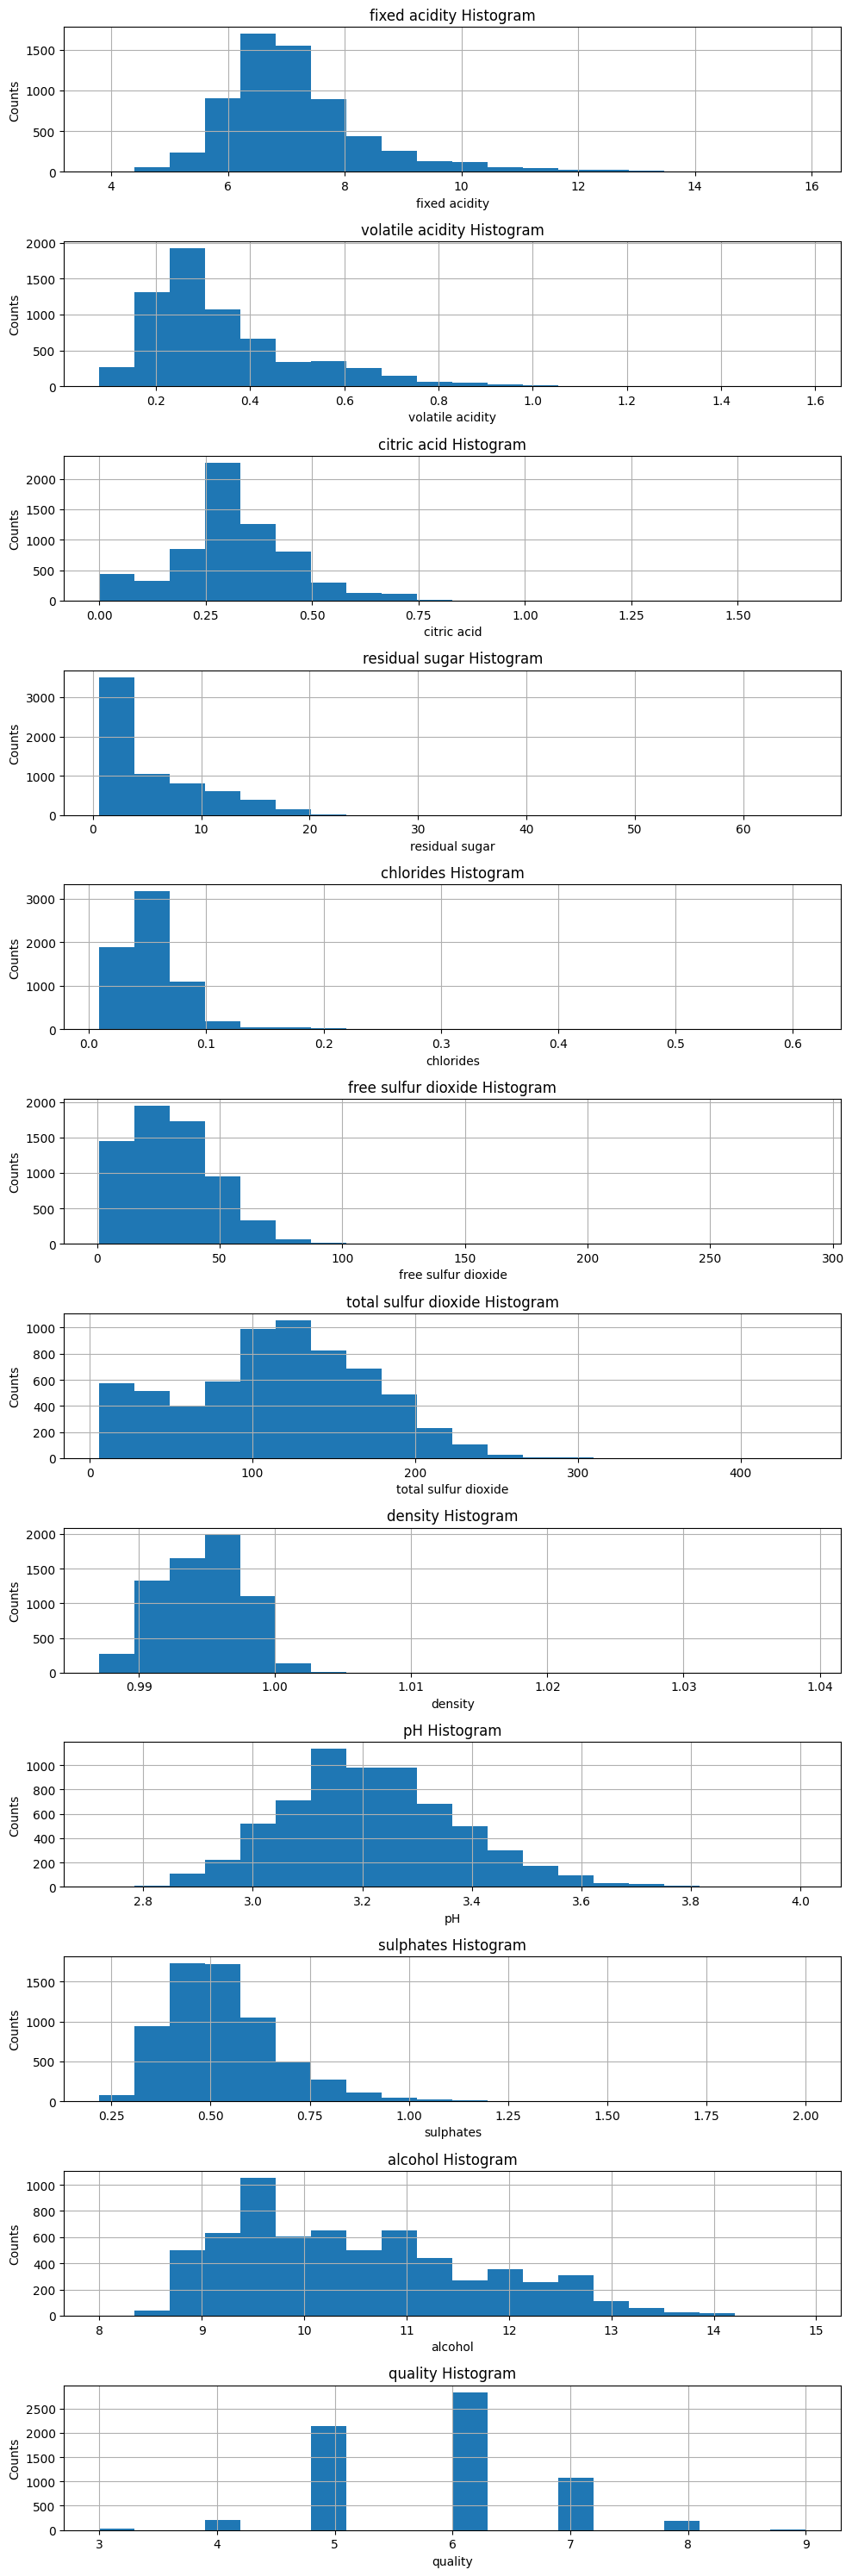

In [31]:
# Input column names into a list
columns = list(df.columns)
columns = columns[1:] # Remove Type column and keep only --> ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

# Get how many columns we have
column_length = len(columns)

# Call subplots to create plot for every column in dataFrame
fig, axes = plt.subplots(column_length, 1, figsize=(10, 30))

# For every column in df create a histogram plot with:
# - General title
# - x and y title
for i, col in enumerate(columns):
  ax = axes[i]
  ax.hist(df[col], bins=20)
  ax.set_xlabel(col)
  ax.set_ylabel("Counts")
  ax.set_title(f"{col} Histogram")
  ax.grid()
  plt.tight_layout() # tight layout keep distances between plots because x label was overlapping title

# Show every plot
plt.show()

### Create bar plot for target value `type`
- Use seaborn library because of the countplot ready function
- Change color for better visualization

*Conclusion: There is a problem regarding there are much uknown types(missing values)*

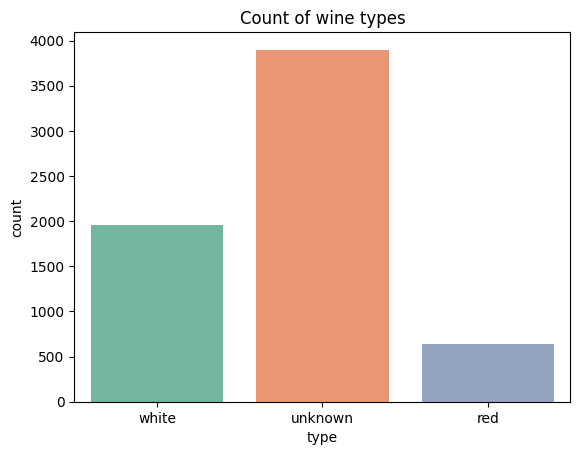

type
unknown    3898
white      1959
red         640
Name: count, dtype: int64


In [32]:
sns.countplot(data=df, x='type', hue='type',palette = "Set2")
plt.title("Count of wine types")
plt.show()
print(df['type'].value_counts())

## Task 2
Convert the values ​​white/red/unknown to 0/1/2 respectively. Then, create numpy arrays x (inputs), y (targets), where x is all variables except type and y is the type.


### Convert Values
- white = 0
- red = 1
- uknown = 2

In [33]:
# Loc the type and change the value
df.loc[df['type'] == 'white', 'type'] = 0
df.loc[df['type'] == 'red', 'type'] = 1
df.loc[df['type'] == 'unknown', 'type'] = 2
df


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,2,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,0,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,2,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,2,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,1,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,1,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,2,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,1,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


### Create numpy arrays x (inputs), y (targets), where x is all variables except type and y is the type.

In [34]:
# Initialize x,y np arrays
x = df.drop('type', axis=1).to_numpy()
y = df['type']
print(x[0])
print(y[0])

[7.000e+00 2.700e-01 3.600e-01 2.070e+01 4.500e-02 4.500e+01 1.700e+02
 1.001e+00 3.000e+00 4.500e-01 8.800e+00 6.000e+00]
0


## Task 3
Create 2 different datasets: (1) (x_known, y_known) and (2) x_unknown. The 1st dataset contains all pairs (inputs, targets) in which the variable type (white/red) is known, while the 2nd contains all inputs where the target is unknown.


In [35]:
# keep only known and pass them to x,y
known = df[(df['type'] == 1) | (df['type'] == 0)]
x_known = known.drop('type', axis=1).to_numpy()
y_known = known['type'].to_numpy().astype(int)

# Get only uknown
uknown = df[df['type'] == 2]
x_uknown = uknown.drop('type', axis=1).to_numpy()
y_uknown = uknown['type'].to_numpy().astype(int)


## Task 4
For the 1st dataset, use the train_test_split() function to split your data into train-test with a percentage of 70-30 respectively. Set random_state=42 and the option stratify=True, so that there is the same percentage of each class in train and test respectively.

**True in stratify ensure that the target variable has the same class proportions so we pass y_known as the value because stratify is getting only np.arrays**

*it turns out it works well since in both train and test set the proportions of labels 1 is the 32% of the labels 0*

In [36]:
# Initialize variables
test_size = 0.3
random_state = 42

# Split dataset with train-test split adding stratify to target so the portions be the same
x_train, x_test, y_train, y_test = train_test_split(x_known, y_known, test_size=test_size, random_state=random_state, stratify=y_known)

train_labels, train_counts = np.unique(y_train, return_counts=True)
test_labels, test_counts = np.unique(y_test, return_counts=True)

# Print results to ensure everything worked well
print("x_train shape: ",x_train.shape)
print("y_train shape: ",y_train.shape)
print("\ny_train labels count: \n", np.asarray((train_labels, train_counts)).T)

print("-"*70)
print("x_test shape: ",x_test.shape)
print("y_test shape: ",y_test.shape)
print("\ny_test labels count: \n",np.asarray((test_labels, test_counts)).T)

x_train shape:  (1819, 12)
y_train shape:  (1819,)

y_train labels count: 
 [[   0 1371]
 [   1  448]]
----------------------------------------------------------------------
x_test shape:  (780, 12)
y_test shape:  (780,)

y_test labels count: 
 [[  0 588]
 [  1 192]]


## Task 5
Train a Random Forest classifier with random_state=42 on the train set and calculate the accuracy, f1-score, precision and recall, on the train and test sets. Which of the 2 metrics is more representative of the dataset: Accuracy or F1? Justify.

In [37]:
# Initialize Random forest with random state = 42
rdf7 = RandomForestClassifier(random_state=random_state)
rdf7.fit(X=x_train, y=y_train)

RandomForestClassifier(random_state=42)

### Train model in train set

### Calculate and show metrices
- F1 score
- Accuracy
- Precision
- Recall

*Setting average='weighted' target is multiclass so default value average = 'binary' is false*

### Question answer
Which of the 2 metrics is more representative of the dataset: Accuracy or F1? Justify.

By looking at the results, the model achieves almost perfect performance on both training and test sets. This observation can be seen by looking at the metrices:

| **Metrics**   | **Train Set** | **Test Set** |
| ------------- | ------------- | ------------ |
| **Accuracy**  | 0.9995        | 0.9987       |
| **F1 Score**  | 0.9989        | 0.9974       |
| **Precision** | 0.9978        | 0.9948       |
| **Recall**    | 1.0000        | 1.0000       |


Train and test set have high metrices values meaning that the model can accurately predict the type of the wine.
F1 score is the more important metric for these problems since it combines precision and recall:
$F_1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}$
and helps to understand model's behaivior for classes. Since model learn how to work with classes with most examples in dataset accuracy is not as helpful as f1-score since its value might mislead.

In [38]:
def calc_metrices(train_pred_y, test_pred_y, averge = 'binary'):
    # Calculate metrices for train
    train_accuracy = accuracy_score(y_train, train_pred_y)
    train_f1 = f1_score(y_train, train_pred_y, average=averge)
    train_prec = precision_score(y_train, train_pred_y, average=averge)
    train_rec = recall_score(y_train, train_pred_y, average=averge)
    print("============== Train Metrices ==============")
    # Print Metrices
    print(f"Accuracy train --> {train_accuracy}")
    print(f"F1 Score train --> {train_f1}")
    print(f"Precision train --> {train_prec}")
    print(f"Recall train --> {train_rec}")

    print("\n============== Test Metrices ==============")
    # Calculate metrices for test
    test_accuracy = accuracy_score(y_test, test_pred_y)
    test_f1 = f1_score(y_test, test_pred_y, average=averge)
    test_prec = precision_score(y_test, test_pred_y, average=averge)
    test_rec = recall_score(y_test, test_pred_y, average=averge)
    # Print metrices
    print(f"Accuracy test --> {test_accuracy}")
    print(f"F1 Score test --> {test_f1}")
    print(f"Precision test --> {test_prec}")
    print(f"Recall test --> {test_rec}")

# Get predictions
train_pred_y = rdf7.predict(x_train)
test_pred_y = rdf7.predict(x_test)
calc_metrices(train_pred_y, test_pred_y)

============== Train Metrices ==============
Accuracy train --> 0.999450247388675
F1 Score train --> 0.9988851727982163
Precision train --> 0.9977728285077951
Recall train --> 1.0

============== Test Metrices ==============
Accuracy test --> 0.9987179487179487
F1 Score test --> 0.9974025974025974
Precision test --> 0.9948186528497409
Recall test --> 1.0


## Task 6
Retrain the Random Forest with random_state=42, setting the parameter class_weight=’balanced’. Explain according to the documentation what the parameter does. Then, calculate the metrics of query 5 again.

### Answer
By looking at the results:

| **Metrics**   | **Train Set** | **Test Set** |
| ------------- | ------------- | ------------ |
| **Accuracy**  | 0.9995        | 0.9949       |
| **F1 Score**  | 0.9989        | 0.9895       |
| **Precision** | 0.9978        | 0.9947       |
| **Recall**    | 1.0000        | 0.9844       |

In training set every value is the same.
All metrices provide a bit worst value. This is happening since we use class_weight = balanced into the model.
As it is mention in scikit learn: `The “balanced” mode uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y))`
It is normal for metrices values to decrease slightly since the model is trying to be more fair to the classes but there is an unbalanced dataset make it difficult to generalize.

In [39]:
# Initialize Random forest with random state = 42
rdf6 = RandomForestClassifier(random_state=random_state, class_weight='balanced')
rdf6.fit(X=x_train, y=y_train)

# Get predictions
train_pred_y = rdf6.predict(x_train)
test_pred_y = rdf6.predict(x_test)

# Call metrices
calc_metrices(train_pred_y, test_pred_y)

============== Train Metrices ==============
Accuracy train --> 0.999450247388675
F1 Score train --> 0.9988851727982163
Precision train --> 0.9977728285077951
Recall train --> 1.0

============== Test Metrices ==============
Accuracy test --> 0.9948717948717949
F1 Score test --> 0.9895287958115183
Precision test --> 0.9947368421052631
Recall test --> 0.984375


## Task 7
Use the classifier in question 6 to calculate the model’s probabilities for the class of each example in the set x_unknown
(y_unknown_proba=model.predict_proba(x_unknown)).

return of the code: ndarray of shape (n_samples, n_classes) providing "confidence of the model" predict if output is 0->white | 1->red

**Real example: **

array([[1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       ...,
       [0.01, 0.99],
       [0.01, 0.99],
       [0.01, 0.99]], shape=(3898, 2))

**This means:**
| **Sample** | **Probability Class 0** | **Probability Class 1** |
| ---------- | ----------------------- | ----------------------- |
| 1          | 1.00 (100%)             | 0.00  (0%)              |
| 2          | 1.00                    | 0.00                    |
| 3          | 1.00                    | 0.00                    |
| ...        | ...                     | ...                     |
| 3896       | 0.01                    | 0.99                    |
| 3897       | 0.01                    | 0.99                    |
| 3898       | 0.01                    | 0.99                    |

*By looking at these values the model is confident about its predictions*

In [40]:
# Get prediction propabilities
uknown_pred_y = rdf6.predict_proba(x_uknown)
uknown_pred_y

array([[1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       ...,
       [0.01, 0.99],
       [0.01, 0.99],
       [0.01, 0.99]])

## Task 8
Label (y_unknown_pred) ‘red’ the examples in the set x_unknown for which y_unknown_proba > 0.65. Similarly, label ‘white’ the examples in the set x_unknown for which x_unknown_proba < 0.35.

In [41]:
# Initialize the list
y_unknown_pred = [] # Model is confident for the label
x_unknown_pred = [] # Model is confident for the label

y_still_uknown = [] # Model is not confident for the label
x_still_uknown = [] # Model is not confident for the label

# For loop checking the propabilities of the model and replace uknown with red/white
for i, p in enumerate(uknown_pred_y):
    if p[1] > 0.65:
        # Red
        y_unknown_pred.append(1)
        x_unknown_pred.append(x_uknown[i])
    elif p[1] < 0.35:
        # White
        y_unknown_pred.append(0)
        x_unknown_pred.append(x_uknown[i])
    else:
        # Uknown
        y_still_uknown.append(2)
        x_still_uknown.append(x_uknown[i])


y_unknown_pred = np.array(y_unknown_pred)
print(np.unique(y_unknown_pred, return_counts = True))
print(len(y_unknown_pred))

(array([0, 1]), array([2939,  908]))
3847


## Task 9
Join the sets (x_train, y_train) of the 1st set with the data labeled in question 8. Then, Retrain the Random Forest and calculate the accuracy on the train/test sets of the 1st data set.


In [42]:
# Combine results from previous question with known data
all_x_train = np.concatenate((x_train, x_unknown_pred))
all_y_train = np.concatenate((y_train, y_unknown_pred))

# Print the len of the new np arrays
print(len(all_x_train))
print(len(all_y_train)) # 6446 --> 50 of the labels are still uknown

5666
5666


### Train the model with new data

In [43]:
rdf6.fit(all_x_train, all_y_train)

# Get predictions
train_pred_y = rdf6.predict(all_x_train)
test_pred_y = rdf6.predict(x_test)

# Call metrices
train_accuracy = accuracy_score(all_y_train, train_pred_y)
test_accuracy = accuracy_score(y_test, test_pred_y)

print(f"Accuracy train --> {train_accuracy}")
print(f"Accuracy test --> {test_accuracy}")


Accuracy train --> 0.9998235086480762
Accuracy test --> 0.9948717948717949


## Task 10
Repeat steps 6-9 until there are no more examples in the unknown that are predicted with high confidence (i.e. have marginal probabilities).

In [44]:
while len(x_still_uknown) > 0:

  # Get prediction propabilities
  uknown_pred_y = rdf6.predict_proba(x_still_uknown)

  # Initialize the list
  y_unknown_pred = [] # Model is confident for the label
  x_unknown_pred = [] # Model is confident for the label

  x_new_unknown = []

  # For loop checking the propabilities of the model and replace uknown with red/white
  for i, p in enumerate(uknown_pred_y):
      if p[1] > 0.65:
          # Red
          y_unknown_pred.append(1)
          x_unknown_pred.append(x_still_uknown[i])
      elif p[1] < 0.35:
          # White
          y_unknown_pred.append(0)
          x_unknown_pred.append(x_still_uknown[i])
      else:
          # Uknown
          x_new_unknown.append(x_still_uknown[i])


  x_still_uknown = np.array(x_new_unknown)
  y_unknown_pred = np.array(y_unknown_pred)
  x_unknown_pred = np.array(x_unknown_pred)

  if len(y_unknown_pred):
      print("Unique values: ",np.unique(y_unknown_pred, return_counts = True))
      print("y_unknown_pred: ",len(y_unknown_pred))

      # Combine results from previous question with known data
      all_x_train = np.concatenate((x_train, x_unknown_pred))
      all_y_train = np.concatenate((y_train, y_unknown_pred))

      # Print the len of the new np arrays
      print("Len all_x_train: ",len(all_x_train))
      print("Len all_y_train: ",len(all_y_train)) # 6446 --> 50 of the labels are still uknown

      # Train model
      rdf6.fit(all_x_train, all_y_train)

      # Get predictions
      train_pred_y = rdf6.predict(all_x_train)
      test_pred_y = rdf6.predict(x_test)

      # Call metrices
      train_accuracy = accuracy_score(all_y_train, train_pred_y)
      test_accuracy = accuracy_score(y_test, test_pred_y)

      print(f"Accuracy train --> {train_accuracy}")
      print(f"Accuracy test --> {test_accuracy}")
  else:
      print(f"Model stop.....\nCannot predict {len(x_new_unknown)} labels")
      break

  print("-"*70)


Unique values:  (array([0, 1]), array([13, 10]))
y_unknown_pred:  23
Len all_x_train:  1842
Len all_y_train:  1842
Accuracy train --> 0.999457111834962
Accuracy test --> 0.9987179487179487
----------------------------------------------------------------------
Unique values:  (array([0]), array([1]))
y_unknown_pred:  1
Len all_x_train:  1820
Len all_y_train:  1820
Accuracy train --> 0.9994505494505495
Accuracy test --> 0.9974358974358974
----------------------------------------------------------------------
Unique values:  (array([1]), array([3]))
y_unknown_pred:  3
Len all_x_train:  1822
Len all_y_train:  1822
Accuracy train --> 0.9994511525795828
Accuracy test --> 0.9974358974358974
----------------------------------------------------------------------
Unique values:  (array([1]), array([2]))
y_unknown_pred:  2
Len all_x_train:  1821
Len all_y_train:  1821
Accuracy train --> 0.99945085118067
Accuracy test --> 0.9987179487179487
---------------------------------------------------------